MODELE DE RESEAU DE NEURONES CONVOLUTIFS

In [1]:
'''
Modifications par rapport au modèle précédent :

- Nettoyage du code

'''

'\nModifications par rapport au modèle précédent :\n\n- Nettoyage du code\n\n'

In [2]:
# Import des librairies principales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# Importation pour la transformation des images
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomContrast


# Imports nécessaires pour construire / sauvegarder / évaluer le modèle
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix


# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory


In [3]:
# Définition des chemins d'accès

rep_img = 'C:\\Users\\Utilisateur\\Documents\\DataScience_images_Especes\\'
rep_model = "C:\\Users\\Utilisateur\\Documents\\DataScience\\avr25cds_reconnaissance_champignons\\models\\"

In [4]:
# Importation de l'utilitaire image_dataset_from_directory de Keras

train_ds = image_dataset_from_directory(
    rep_img,
    validation_split=0.30,     # 30% réservé pour val + test
    subset="training",
    seed=42,
    batch_size=64,
    image_size=(224, 224)
)

# Dataset temporaire qui va être divisé en 15% validation et 15% test
temp_ds = image_dataset_from_directory(
    rep_img,
    validation_split=0.30,
    subset="validation",
    seed=42,
    batch_size=64,
    image_size=(224, 224)
)


Found 19216 files belonging to 30 classes.
Using 13452 files for training.
Found 19216 files belonging to 30 classes.
Using 5764 files for validation.


In [5]:
# Découpage du dataset temp en validation + test


temp_size = tf.data.experimental.cardinality(temp_ds).numpy()

val_size = temp_size // 2
test_size = temp_size - val_size

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

In [6]:
# Optimisation du pipeline

AUTOTUNE = tf.data.AUTOTUNE   # Optimisation automatique du nombre de fichiers et threads à charger

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE) # Pour garder en mémoire les images et gagner en vitesse // shuffle pour mélanger les images à chaque epoch pour un meilleur apprentissage
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [7]:
# Nombre de lot dans l'ensemble d'entraînement
print("Nombre de batch dans train_ds:", train_ds.cardinality().numpy())

# Nombre de lot dans l'ensemble de validation
print("Nombre de batch dans val_ds:", val_ds.cardinality().numpy())

# Nombre de lot dans l'ensemble de test
print("Nombre de batch dans test_ds:", test_ds.cardinality().numpy())

Nombre de batch dans train_ds: 211
Nombre de batch dans val_ds: 45
Nombre de batch dans test_ds: 46


In [8]:
# Définir des couches de transformation
random_translation = RandomTranslation(0.1, 0.1)   # Étirement
random_zoom = RandomZoom(0.1)                      # Agrandissement
random_flip = RandomFlip("horizontal")             # Retournement horizontal
random_rotation = RandomRotation(0.1)              # Rotation
random_contrast = RandomContrast(0.1)              # Contraste

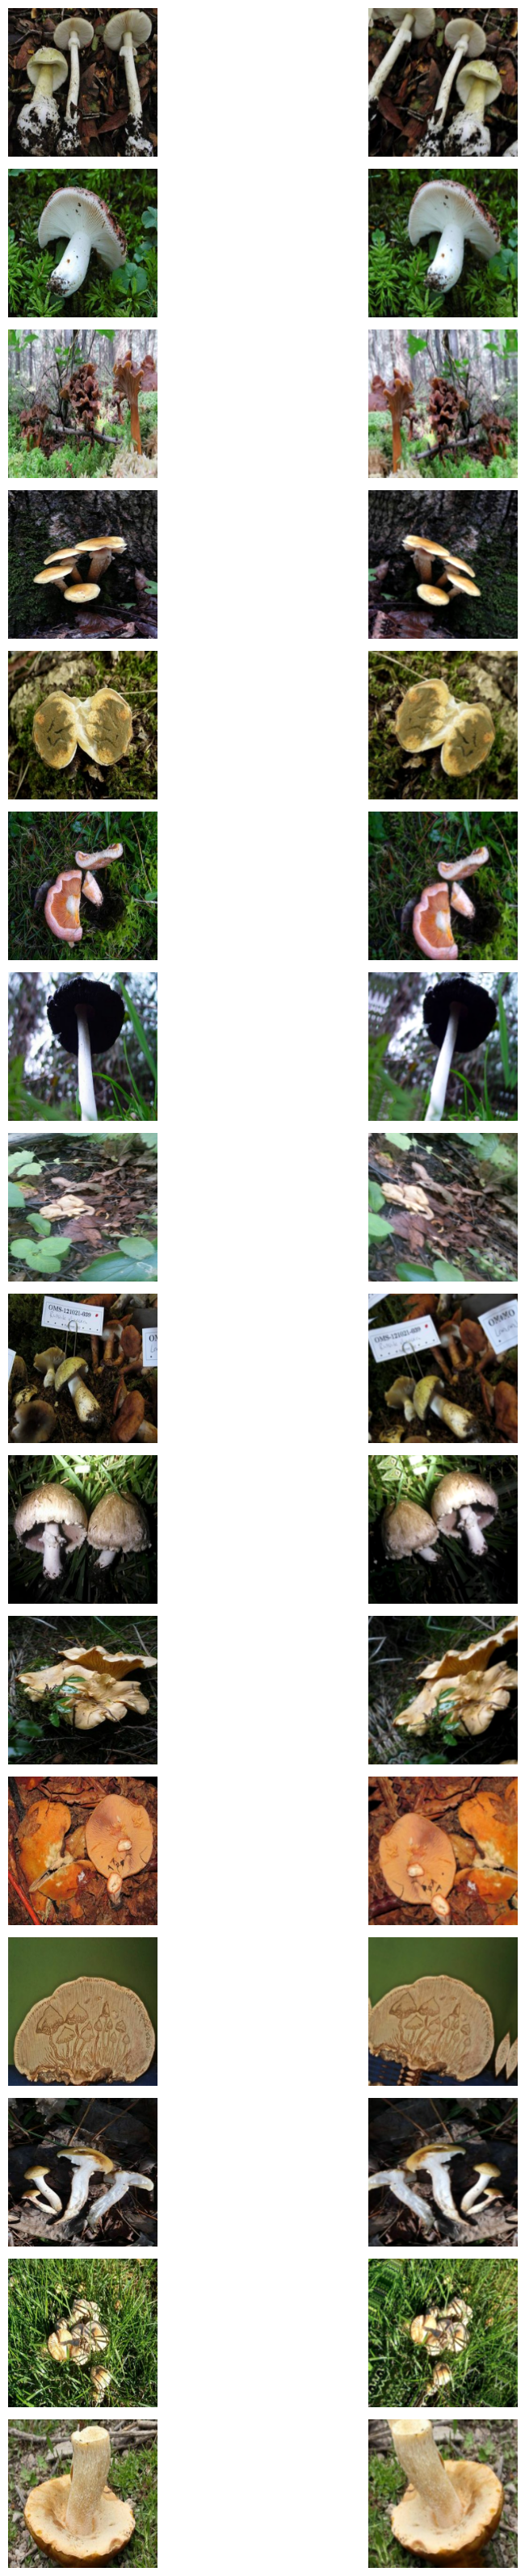

In [9]:
# Récupération de 16 images et affichage

for batch_images, batch_labels in train_ds.take(1):
    images = batch_images[:16]
    labels = batch_labels[:16]

plt.figure(figsize=(12, 32))

for i in range(16):
    image = images[i]  # Récupérer la ième image
    
    # Appliquer les transformations
    x = random_translation(image)   # Etirement   
    x = random_zoom(x)              # Zoom       
    x = random_flip(x)              # Retournement
    x = random_rotation(x)          # Rotation
    x = random_contrast(x)          # Contraste   
        
    # Afficher l'image originale
    plt.subplot(16, 2, 2*i + 1)  # Position dans la grille
    plt.imshow(image.numpy().astype("uint8")) 
    plt.axis("off")
    
    # Afficher l'image transformée
    plt.subplot(16, 2, 2*i + 2)  # Position dans la grille
    plt.imshow(x.numpy().astype("uint8"))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# Paramétrage du CNN

# Entrée du modèle
inputs = Input(shape=(224, 224, 3))


# Transformation des images :
x = random_translation(inputs)    # Etirement   
x = random_zoom(x)                     # Zoom       
x = random_flip(x)            # Retournement
x = random_rotation(x)                 # Rotation
x = random_contrast(x)                 # Contraste
x = Rescaling(1./255)(x)                    # Normalisation
#x = Resizing(64, 64)(x)        # Redimensionnement Inutile, on garde la taille originale des photos



# Première couche de convolution
conv2d_1 = Conv2D(
    filters=32,
    kernel_size=(3, 3),  #on passe de (4, 4) à (3, 3)
    padding='same',   # same mieux que valid car ne réduit pas l'image
    activation='relu',
)
x = BatchNormalization()(x) # stabilise et accélère l’apprentissage
x = conv2d_1(x)   


# Première couche de pooling
max_pooling2d_1 = MaxPooling2D(pool_size=(2, 2),)  
x = max_pooling2d_1(x)


# Deuxième couche de convolution
conv2d_2 = Conv2D(
    filters=64,                    
    kernel_size=(3, 3),            
    padding='same',             
    activation='relu',
)
x = conv2d_2(x)


# Deuxième couche de pooling
max_pooling2d_2 = MaxPooling2D(pool_size=(2, 2),)  
x = max_pooling2d_2(x)


# Troisième couche de convolution
conv2d_3 = Conv2D(
    filters=128,                    
    kernel_size=(3, 3),            
    padding='same',             
    activation='relu',
)
x = conv2d_3(x)


# Troisème couche de pooling
max_pooling2d_3 = MaxPooling2D(pool_size=(2, 2),)  
x = max_pooling2d_3(x)


# Couche de Flatten
flatten = Flatten()
x = flatten(x)


# Première couche dense
dense_1 = Dense(
    units=256,
    activation='relu',
)
x = dense_1(x)


# Couche de sortie
dense_2 = Dense(
    units=30,
    activation='softmax',
)
outputs = dense_2(x)

model_cnn = Model(inputs=inputs, outputs=outputs)

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Callback pour sauvegarder le modèle
save = ModelCheckpoint(
    rep_model+'CNN_model.h5',
    save_best_only=True, 
    monitor='val_accuracy',
    mode='max'
)

# Callback pour réduire le taux d'apprentissage
reduceLR = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3,
                                    min_delta=0.01,
                                    factor=0.1, 
                                    cooldown=4)

# Callback pour stopper l'apprentissage quand il ne progresse plus
early_stop = EarlyStopping(
                                patience=5,     # Nombre d'époques sans amélioration avant arrêt
                                min_delta=0.01, 
                                mode='min',
                                monitor='val_loss') # On surveille la perte sur l'ensemble de validation

In [12]:
# Compilation du modèle
model_cnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [13]:
# Entrainement du modèle
history_model = model_cnn.fit(train_ds,
                    validation_data=val_ds,
                    epochs=50,
                    callbacks = [reduceLR, save, early_stop])

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.0648 - loss: 4.0743

211/211 ━━━━━━━━━━━━━━━━━━━━ 80s 376ms/step - accuracy: 0.0649 - loss: 4.0712 - val_accuracy: 0.1080 - val_loss: 3.1552 - learning_rate: 0.0010
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.1153 - loss: 3.1053

211/211 ━━━━━━━━━━━━━━━━━━━━ 79s 375ms/step - accuracy: 0.1153 - loss: 3.1051 - val_accuracy: 0.1521 - val_loss: 2.9825 - learning_rate: 0.0010
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.1548 - loss: 2.9565

211/211 ━━━━━━━━━━━━━━━━━━━━ 79s 373ms/step - accuracy: 0.1549 - loss: 2.9562 - val_accuracy: 0.2000 - val_loss: 2.8028 - learning_rate: 0.0010
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.2035 - loss: 2.7664

211/211 ━━━━━━━━━━━━━━━━━━━━ 79s 374ms/step - accuracy: 0.2035 - loss: 2.7662 - val_accuracy: 0.2330 - val_loss: 2.6536 - learning_rate: 0.0010
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.2512 - loss: 2.5695

...

211/211 ━━━━━━━━━━━━━━━━━━━━ 78s 372ms/step - accuracy: 0.6140 - loss: 1.2801 - val_accuracy: 0.5344 - val_loss: 1.6941 - learning_rate: 1.0000e-04
Epoch 22/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6244 - loss: 1.2398

211/211 ━━━━━━━━━━━━━━━━━━━━ 80s 378ms/step - accuracy: 0.6245 - loss: 1.2398 - val_accuracy: 0.5368 - val_loss: 1.7009 - learning_rate: 1.0000e-04
Epoch 23/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.6375 - loss: 1.2112

211/211 ━━━━━━━━━━━━━━━━━━━━ 79s 373ms/step - accuracy: 0.6375 - loss: 1.2112 - val_accuracy: 0.5410 - val_loss: 1.7036 - learning_rate: 1.0000e-04
Epoch 24/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.6361 - loss: 1.2192

211/211 ━━━━━━━━━━━━━━━━━━━━ 78s 372ms/step - accuracy: 0.6362 - loss: 1.2191 - val_accuracy: 0.5413 - val_loss: 1.6885 - learning_rate: 1.0000e-05
Epoch 25/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.6409 - loss: 1.1864

211/211 ━━━━━━━━━━━━━━━━━━━━ 79s 373ms/step - accuracy: 0.6409 - loss: 1.1864 - val_accuracy: 0.5448 - val_loss: 1.6859 - learning_rate: 1.0000e-05
Epoch 26/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 79s 375ms/step - accuracy: 0.6529 - loss: 1.1665 - val_accuracy: 0.5403 - val_loss: 1.6878 - learning_rate: 1.0000e-05
Epoch 27/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 79s 373ms/step - accuracy: 0.6486 - loss: 1.1837 - val_accuracy: 0.5410 - val_loss: 1.6881 - learning_rate: 1.0000e-05
Epoch 28/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 78s 371ms/step - accuracy: 0.6417 - loss: 1.1902 - val_accuracy: 0.5403 - val_loss: 1.6909 - learning_rate: 1.0000e-05
Epoch 29/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 78s 371ms/step - accuracy: 0.6512 - loss: 1.1853 - val_accuracy: 0.5406 - val_loss: 1.6944 - learning_rate: 1.0000e-05
Epoch 30/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 79s 373ms/step - accuracy: 0.6490 - loss: 1.1705 - val_accuracy: 0.5427 - val_loss: 1.6933 - learning_rate: 1.0000e-06


In [14]:
np.save(rep_model+"CNN_model_history.npy", history_model.history)

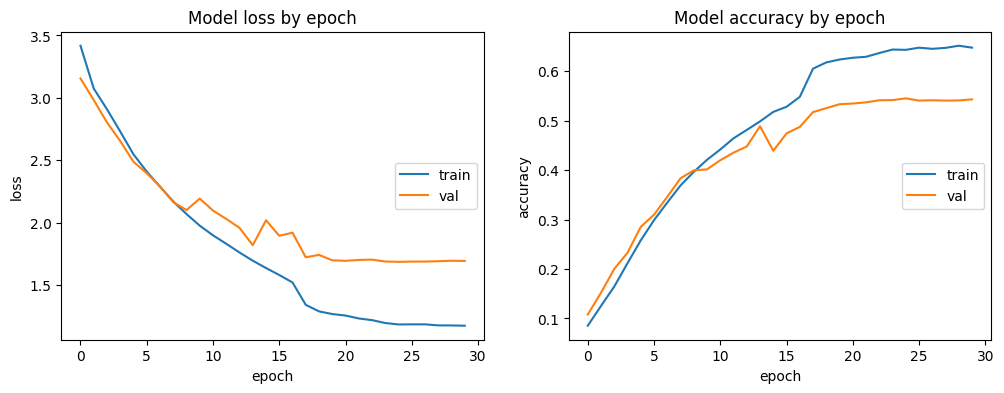

In [15]:
plt.figure(figsize=(12,4))

plt.subplot(121)
plt.plot(history_model.history['loss'])
plt.plot(history_model.history['val_loss'])
plt.title('Model loss by epoch')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='right')

plt.subplot(122)
plt.plot(history_model.history['accuracy'])
plt.plot(history_model.history['val_accuracy'])
plt.title('Model accuracy by epoch')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='right')
plt.show()

In [16]:
# Fonction pour obtenir les prédictions

def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:
        
        preds = model_cnn.predict(images, verbose=0)
        pred_labels.extend(np.argmax(preds, axis=-1))

        true_labels.extend(labels.numpy())

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(test_ds)

# Afficher le rapport de classification
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.76      0.79      0.78        68
           1       0.41      0.53      0.46        89
           2       0.69      0.55      0.61       154
           3       0.37      0.45      0.40       130
           4       0.28      0.12      0.17        98
           5       0.51      0.37      0.42       104
           6       0.91      0.76      0.83        84
           7       0.38      0.30      0.34       152
           8       0.72      0.70      0.71        76
           9       0.49      0.51      0.50        73
          10       0.47      0.46      0.47       146
          11       0.66      0.73      0.69        79
          12       0.48      0.47      0.47        66
          13       0.44      0.39      0.41       148
          14       0.41      0.35      0.38        71
          15       0.51      0.64      0.57        77
          16       0.55      0.56      0.56        80
          17       0.45    

<Axes: >

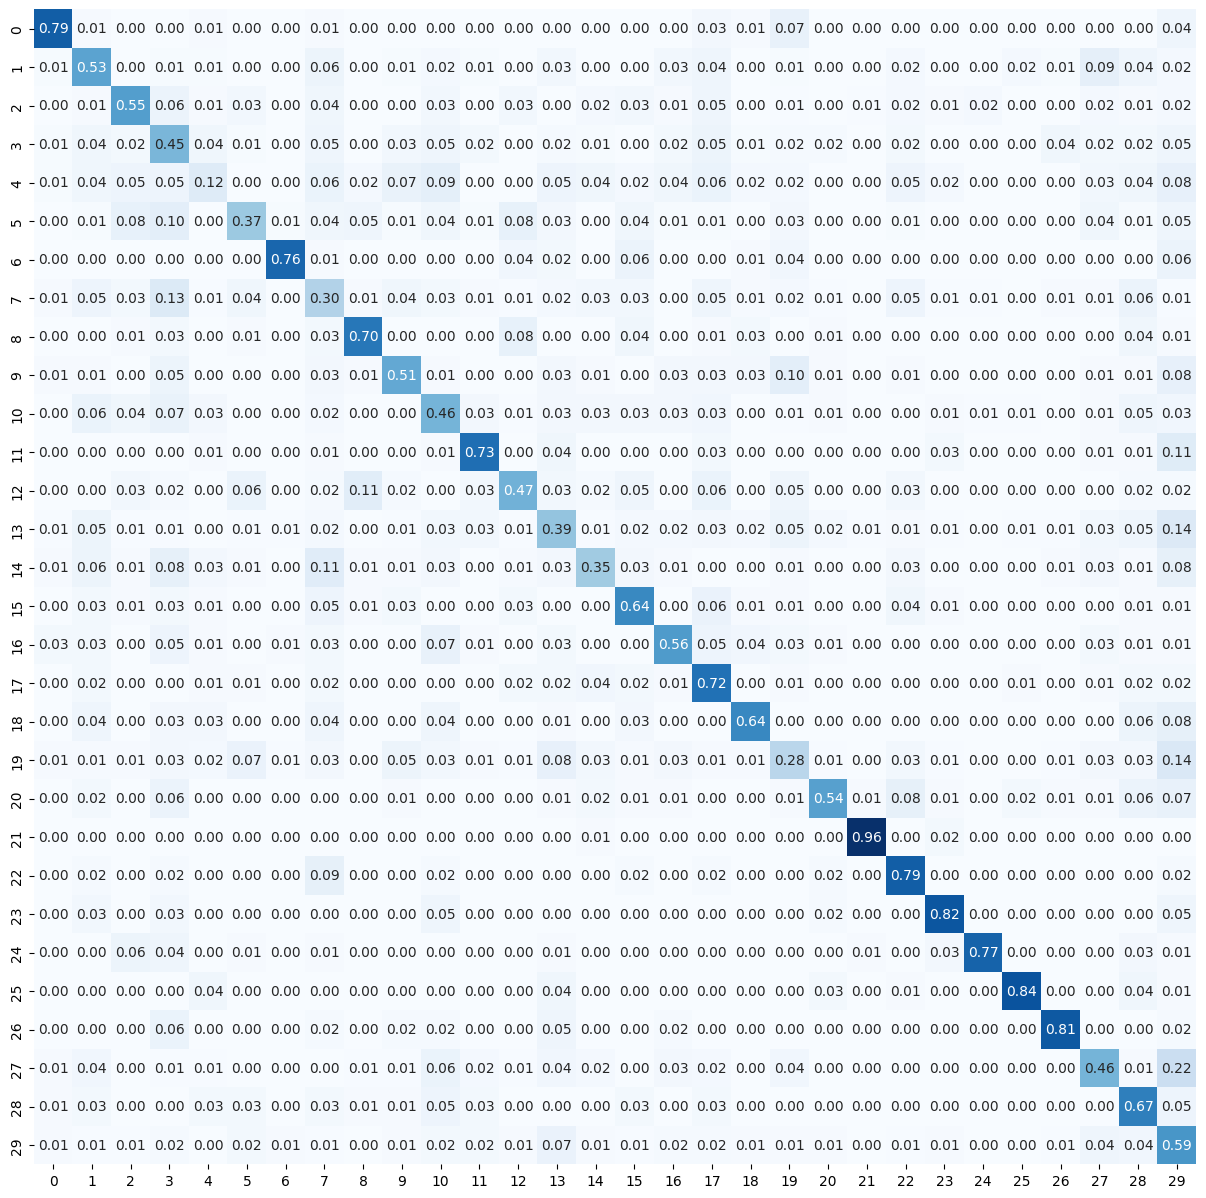

In [17]:
# Affichage de la matrice de confusion

plt.figure(figsize=(15, 15))
cnf_matrix = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")